In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the 4D-var/lorenz directory 
LORENZ_DIR = Path.cwd()

# Default to the standard results folder
RESULTS_DIR = LORENZ_DIR / "outputs" / "results_seed_42_submit_v2_Float_64"

print(f"Using results directory: {RESULTS_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using results directory: /Odyssey/private/c23bouna/UE_G/score-da-demo/4D-avr/lorenz/outputs/results_seed_42_submit_v2_Float_64


## Weak-4DVar Analysis


In [15]:
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))

rc = {
    'axes.axisbelow': True,
    'axes.linewidth': 1.0,
    'axes.prop_cycle': plt.cycler('color', colors),
    'figure.dpi': 150,
    'figure.figsize': (6.4, 4.8),
    'font.size': 12.0,
    'legend.fontsize': 'xx-small',
    'lines.linewidth': 1.0,
    'lines.markersize': 2.5,
    'savefig.transparent': True,
    'xtick.labelsize': 'x-small',
    'xtick.major.width': 1.0,
    'ytick.labelsize': 'x-small',
    'ytick.major.width': 1.0,
    'font.family': ['serif'],
    'text.usetex': True,
}

plt.rcParams.update(rc)

## 2. Load Configurations

In [16]:
# Load all configs and build merged table (no plot in this cell)
import os

CONFIG_META = {
    "results_seed_42_iter_10": {"iter": 10, "bs": 1.0, "dtype": "float64"},
    "results_seed_42_iter_20_bs_0_1": {"iter": 20, "bs": 0.1, "dtype": "float64"},
    "results_seed_42_iter_20_bs_0_5": {"iter": 20, "bs": 0.5, "dtype": "float64"},
    "results_seed_42_iter_20": {"iter": 20, "bs": 1.0, "dtype": "float64"},
    "results_seed_42_iter_20_bs_2_0": {"iter": 20, "bs": 2.0, "dtype": "float64"},
    "results_seed_42_iter_20_bs_5_0": {"iter": 20, "bs": 5.0, "dtype": "float64"},
    "results_seed_42_iter_200": {"iter": 200, "bs": 1.0, "dtype": "float32"},
    "results_seed_42_submit_v2_Float_64": {"iter": 200, "bs": 1.0, "dtype": "float64"},
}

OUTPUTS_DIR = LORENZ_DIR / "outputs"
all_data = []

# Keep declaration order from CONFIG_META
declared_config_order = list(CONFIG_META.keys())

for dirname in declared_config_order:
    result_path = OUTPUTS_DIR / dirname
    if result_path.is_dir():
        for freq in ["lo", "hi"]:
            csv_path = result_path / f"stats_{freq}.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path, header=None, names=["i", "method", "setting", "log_px", "log_py", "w1"])
                df["freq"] = freq
                df["config"] = dirname
                all_data.append(df)

if not all_data:
    raise RuntimeError("No CSV files found under outputs for configured runs.")

all_df = pd.concat(all_data, ignore_index=True)
present_configs = set(all_df["config"].unique().tolist())
config_order = [cfg for cfg in declared_config_order if cfg in present_configs]

# Build configs dict for downstream analysis cells
configs = {}
for dirname in config_order:
    result_path = OUTPUTS_DIR / dirname
    lo_csv = result_path / "stats_lo.csv"
    hi_csv = result_path / "stats_hi.csv"
    if lo_csv.exists() and hi_csv.exists():
        meta = CONFIG_META[dirname]
        dfs = [
            pd.read_csv(result_path / f"stats_{freq}.csv", header=None,
                        names=["i", "method", "setting", "log_px", "log_py", "w1"]).assign(freq=freq, config=dirname)
            for freq in ["lo", "hi"]
        ]
        configs[dirname] = {"meta": meta, "data": pd.concat(dfs, ignore_index=True)}

print(f"Loaded {len(configs)} configs in declaration order")

Loaded 8 configs in declaration order


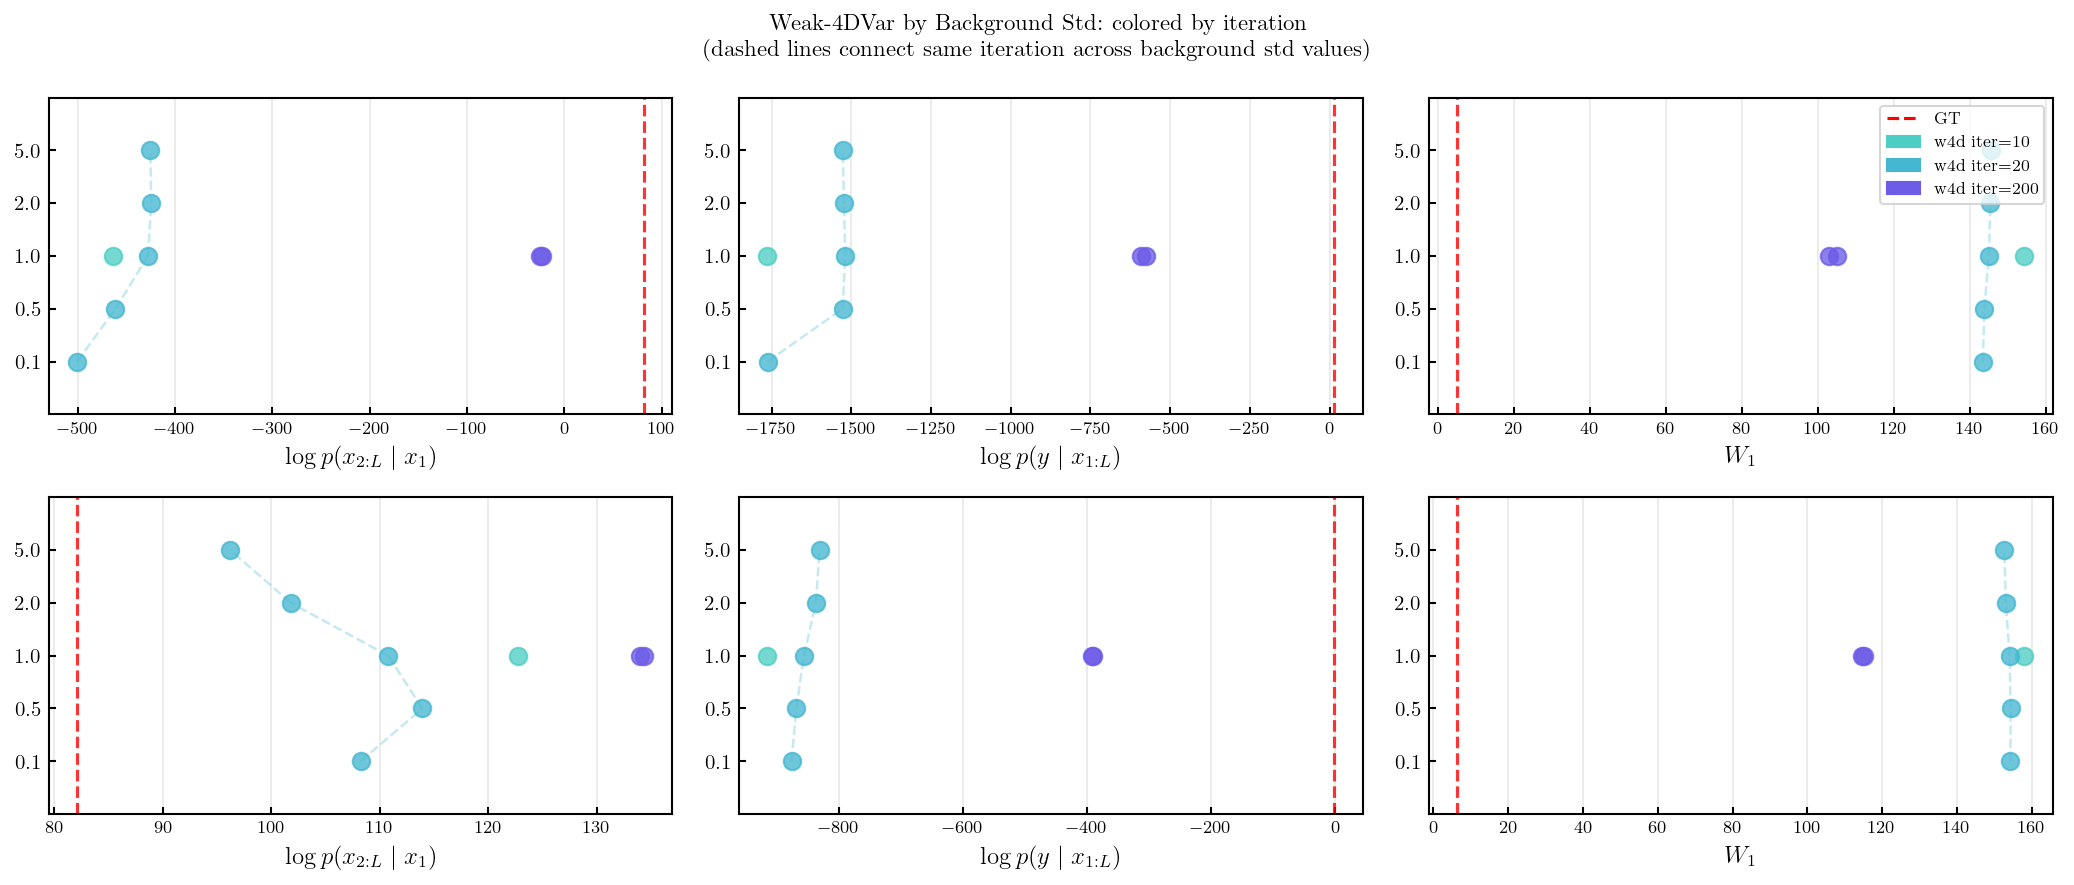

In [ ]:
# Alternate view: background std on Y-axis, iteration in legend
fig, axs = plt.subplots(2, 3, figsize=(14, 6))

metrics = [
    ("log_px", "$\\log p(x_{2:L} \\mid x_1)$"),
    ("log_py", "$\\log p(y \\mid x_{1:L})$"),
    ("w1", "$W_1$"),
]

# Keep iterations in declaration order, but force bs axis to be ascending
iter_order = []
for cfg in config_order:
    it = CONFIG_META[cfg]["iter"]
    if it not in iter_order:
        iter_order.append(it)
bs_order = sorted({CONFIG_META[cfg]["bs"] for cfg in config_order})

# Dynamic colors for iterations
iter_palette = ["#4ECDC4", "#45B7D1", "#6C5CE7", "#F39C12", "#2ECC71", "#E74C3C"]
iter_colors = {it: iter_palette[i % len(iter_palette)] for i, it in enumerate(iter_order)}

# Map bs to y positions with extra margin at bottom/top
bs_to_y = {bs: i + 1 for i, bs in enumerate(bs_order)}
y_pos = np.arange(len(bs_order)) + 1
y_min, y_max = 0, len(bs_order) + 1

for row, freq in enumerate(("lo", "hi")):
    for col_idx, (column, xlabel) in enumerate(metrics):
        ax = axs[row, col_idx]
        freq_data = all_df[all_df["freq"] == freq]

        # GT vertical dashed line
        gt_data = freq_data[freq_data["method"] == "ground-truth"]
        gt_median = gt_data[column].median()
        if pd.notna(gt_median):
            ax.axvline(gt_median, color="red", linestyle="--", linewidth=1.5, alpha=0.8, zorder=1)

        # Plot points: color by iter, y by bs
        plotted_iter = set()
        for cfg in config_order:
            cfg_data = freq_data[freq_data["config"] == cfg]
            if cfg_data.empty:
                continue

            it = CONFIG_META[cfg]["iter"]
            bs = CONFIG_META[cfg]["bs"]
            w4d_series = cfg_data[cfg_data["method"] == "weak-4dvar"][column]
            if w4d_series.empty:
                continue

            w4d_val = w4d_series.median()
            y = bs_to_y[bs]
            label_it = f"iter={it}" if it not in plotted_iter else ""
            ax.scatter([w4d_val], [y], color=iter_colors[it], s=70, alpha=0.78, marker="o", label=label_it, zorder=3)
            plotted_iter.add(it)

        # Connect same iter across bs values
        for it in iter_order:
            it_cfgs = [cfg for cfg in config_order if CONFIG_META[cfg]["iter"] == it]
            if len(it_cfgs) > 1:
                pts = []
                ys = []
                for cfg in sorted(it_cfgs, key=lambda c: bs_order.index(CONFIG_META[c]["bs"])):
                    cfg_data = freq_data[freq_data["config"] == cfg]
                    if cfg_data.empty:
                        continue
                    w4d_series = cfg_data[cfg_data["method"] == "weak-4dvar"][column]
                    if w4d_series.empty:
                        continue
                    pts.append(w4d_series.median())
                    ys.append(bs_to_y[CONFIG_META[cfg]["bs"]])

                for j in range(len(pts) - 1):
                    ax.plot([pts[j], pts[j + 1]], [ys[j], ys[j + 1]], color=iter_colors[it], linestyle="--", alpha=0.3, linewidth=1.2, zorder=2)

        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([str(bs_order[i]) for i in range(len(bs_order))], fontsize=10)
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.3, axis="x")
        ax.tick_params(direction="in")

        if row == 0 and col_idx == 2:
            handles = [mpl.lines.Line2D([0], [0], color="red", linestyle="--", linewidth=1.5, label="GT")]
            for it in iter_order:
                handles.append(mpl.patches.Patch(color=iter_colors[it], label=f"w4d iter={it}"))
            ax.legend(handles=handles, fontsize=8, loc="upper right")

fig.suptitle("Weak-4DVar by Background Std: colored by iteration\n(dashed lines connect same iteration across background std values)", fontsize=11)
fig.tight_layout()
plt.show()

## 3. Compare Across Configurations

In [18]:
# Compute comparison stats (w4d vs GT)
results = []
for dirname, cfg_info in configs.items():
    meta = cfg_info["meta"]
    df = cfg_info["data"]
    
    for freq in ["lo", "hi"]:
        gt = df[(df["freq"] == freq) & (df["method"] == "ground-truth")][["i", "log_px", "log_py", "w1"]]
        w4d = df[(df["freq"] == freq) & (df["method"] == "weak-4dvar")][["i", "log_px", "log_py", "w1"]]
        merged = gt.merge(w4d, on="i", suffixes=("_gt", "_w4d"))
        
        if len(merged) > 0:
            results.append({
                "config": dirname, "iter": meta["iter"], "bs": meta["bs"], "dtype": meta["dtype"], "freq": freq,
                "w1_median": merged["w1_w4d"].median() / (merged["w1_gt"].median() + 1e-8),
                "w1_mean": merged["w1_w4d"].mean() / (merged["w1_gt"].mean() + 1e-8),
                "log_py_delta": (merged["log_py_w4d"] - merged["log_py_gt"]).median(),
            })

comparison_df = pd.DataFrame(results)
print("\nBest configs (W1 ratio):")
for freq in ["lo", "hi"]:
    best = comparison_df[comparison_df["freq"] == freq].nsmallest(1, "w1_median").iloc[0]
    print(f"{freq.upper()}: {best['config']} (iter={best['iter']}, bs={best['bs']}) -> W1_ratio={best['w1_median']:.3f}")


Best configs (W1 ratio):
LO: results_seed_42_iter_200 (iter=200, bs=1.0) -> W1_ratio=19.780
HI: results_seed_42_iter_200 (iter=200, bs=1.0) -> W1_ratio=17.575


### 3.1 Compare All Configs

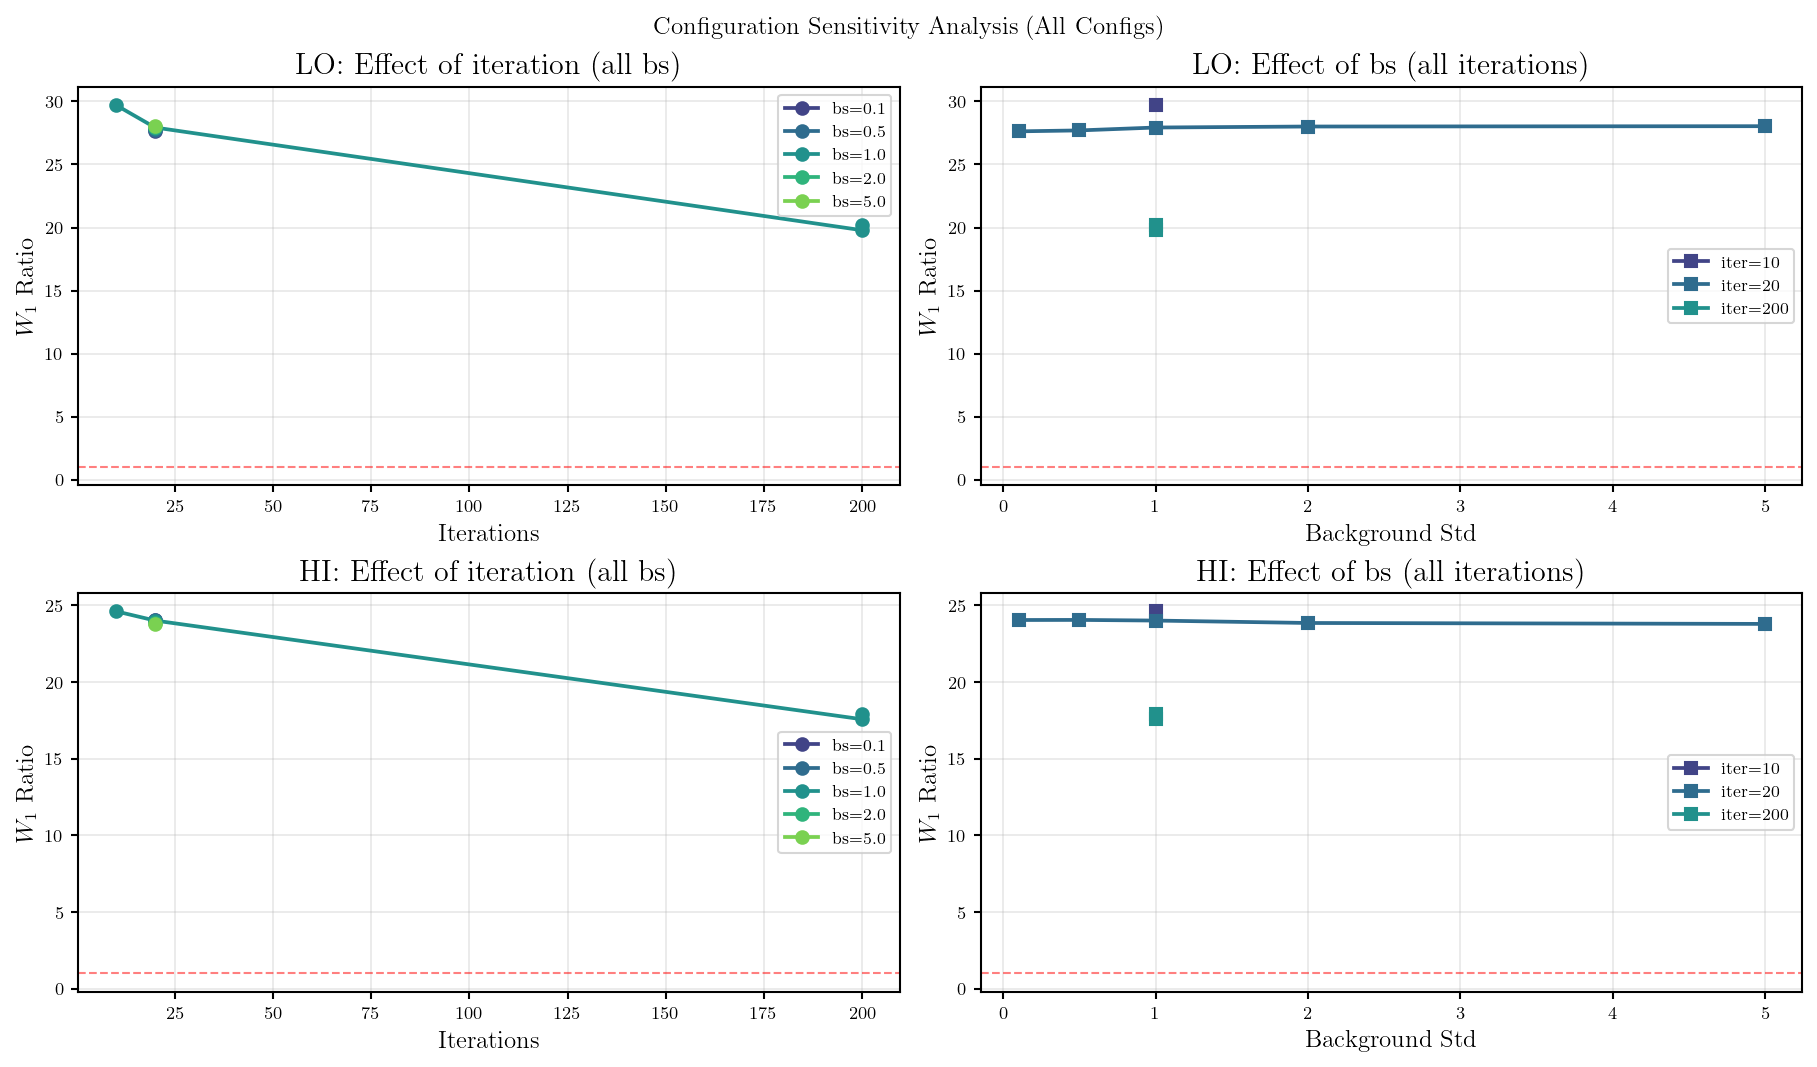

In [19]:
# Plot 1: W1 ratio sensitivity using all loaded configs
fig, axs = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

for row, freq in enumerate(["lo", "hi"]):
    df_freq = comparison_df[comparison_df["freq"] == freq].copy()

    # Left: effect of iterations for each bs
    ax_left = axs[row, 0]
    bs_vals = sorted(df_freq["bs"].unique())
    for bs in bs_vals:
        data = df_freq[df_freq["bs"] == bs].sort_values("iter")
        if len(data) > 0:
            ax_left.plot(data["iter"], data["w1_median"], "o-", linewidth=1.8, markersize=6, label=f"bs={bs}")
    ax_left.axhline(1.0, ls="--", color="red", alpha=0.5)
    ax_left.set_xlabel("Iterations")
    ax_left.set_ylabel(r"$W_1$ Ratio")
    ax_left.set_title(f"{freq.upper()}: Effect of iteration (all bs)")
    ax_left.grid(alpha=0.3)
    ax_left.legend(fontsize=8)

    # Right: effect of background std for each iteration
    ax_right = axs[row, 1]
    iter_vals = sorted(df_freq["iter"].unique())
    for it in iter_vals:
        data = df_freq[df_freq["iter"] == it].sort_values("bs")
        if len(data) > 0:
            ax_right.plot(data["bs"], data["w1_median"], "s-", linewidth=1.8, markersize=6, label=f"iter={it}")
    ax_right.axhline(1.0, ls="--", color="red", alpha=0.5)
    ax_right.set_xlabel("Background Std")
    ax_right.set_ylabel(r"$W_1$ Ratio")
    ax_right.set_title(f"{freq.upper()}: Effect of bs (all iterations)")
    ax_right.grid(alpha=0.3)
    ax_right.legend(fontsize=8)

plt.suptitle("Configuration Sensitivity Analysis (All Configs)", fontsize=12)
plt.show()

## 4. Sensitivity Analysis

In [20]:
# Summary table
for freq in ["lo", "hi"]:
    print(f"\n{freq.upper()} - Rankings (lower W1 ratio is better):")
    print("-" * 70)
    rank_df = comparison_df[comparison_df["freq"] == freq][["config", "iter", "bs", "w1_median", "log_py_delta"]].sort_values("w1_median")
    rank_df["config"] = rank_df["config"].str.replace("results_seed_42_", "").str.replace("results8", "")
    for idx, row in rank_df.iterrows():
        print(f"{row['config']:30s} | iter={int(row['iter']):3d} bs={row['bs']:4.1f} | W1={row['w1_median']:6.3f} | Δlog_py={row['log_py_delta']:8.1f}")


LO - Rankings (lower W1 ratio is better):
----------------------------------------------------------------------
iter_200                       | iter=200 bs= 1.0 | W1=19.780 | Δlog_py=  -602.3
submit_v2_Float_64             | iter=200 bs= 1.0 | W1=20.233 | Δlog_py=  -589.8
iter_20_bs_0_1                 | iter= 20 bs= 0.1 | W1=27.623 | Δlog_py= -1777.3
iter_20_bs_0_5                 | iter= 20 bs= 0.5 | W1=27.697 | Δlog_py= -1541.0
iter_20                        | iter= 20 bs= 1.0 | W1=27.927 | Δlog_py= -1532.7
iter_20_bs_2_0                 | iter= 20 bs= 2.0 | W1=28.006 | Δlog_py= -1536.2
iter_20_bs_5_0                 | iter= 20 bs= 5.0 | W1=28.032 | Δlog_py= -1540.2
iter_10                        | iter= 10 bs= 1.0 | W1=29.717 | Δlog_py= -1777.3

HI - Rankings (lower W1 ratio is better):
----------------------------------------------------------------------
iter_200                       | iter=200 bs= 1.0 | W1=17.575 | Δlog_py=  -390.9
submit_v2_Float_64             | iter=200 b

## 5. Summary Rankings

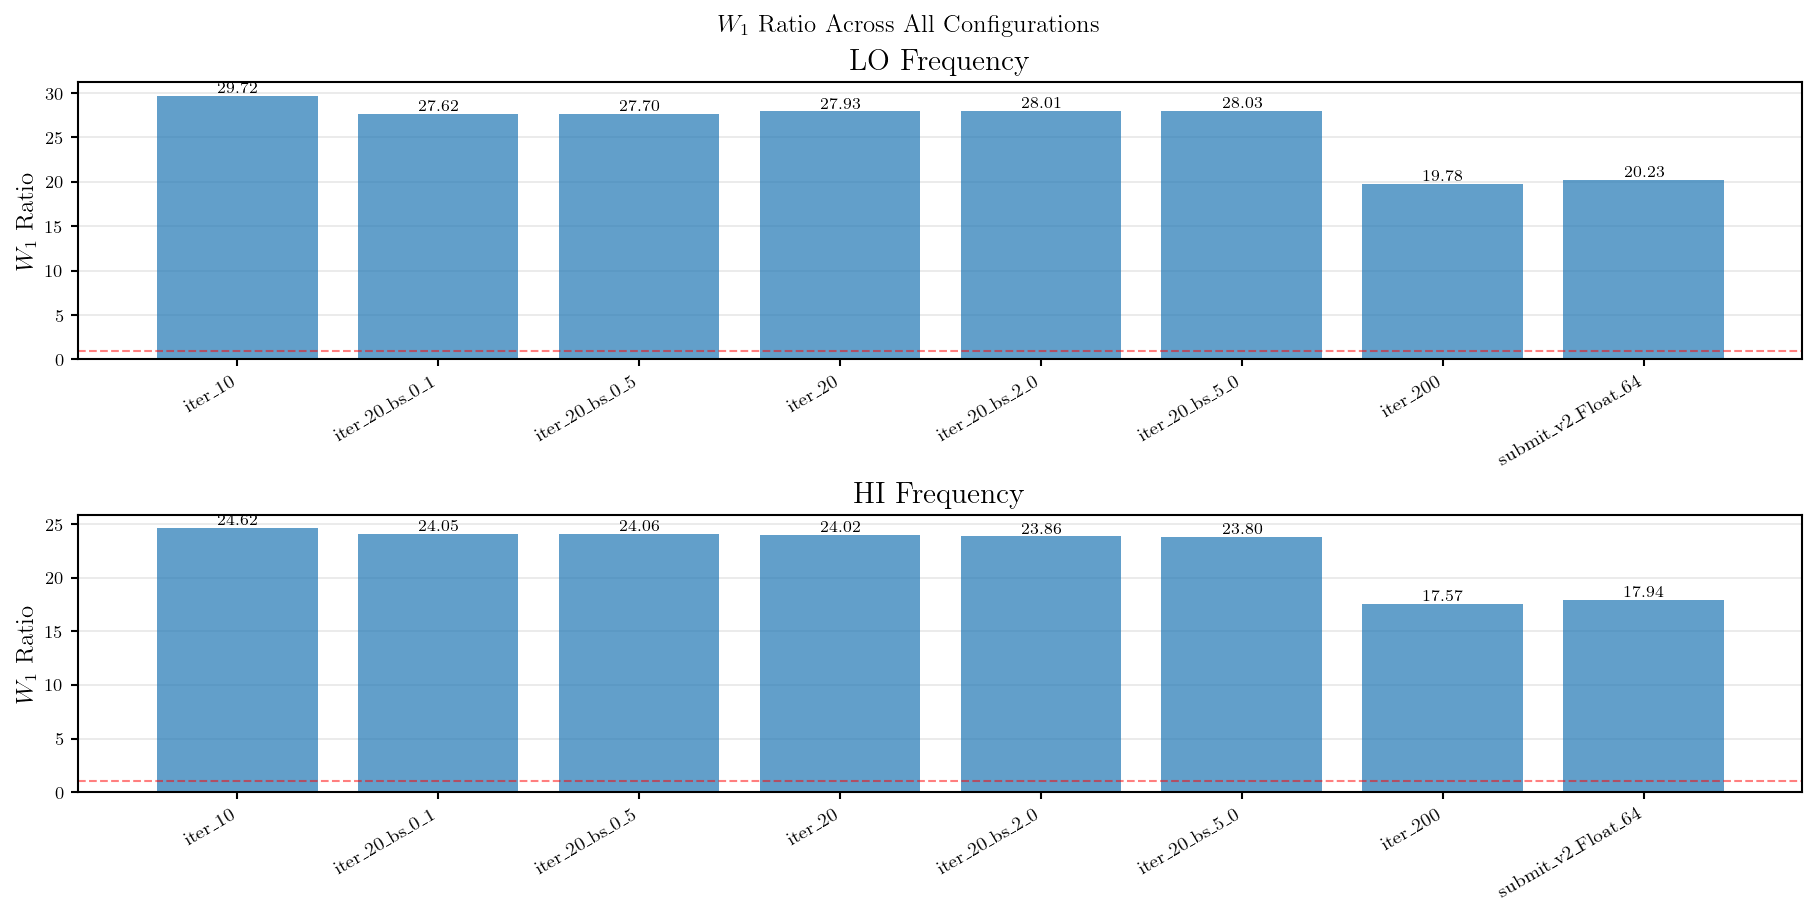

In [21]:
# Plot 2: All configs comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

for ax, freq in zip([ax1, ax2], ["lo", "hi"]):
    data = comparison_df[comparison_df["freq"] == freq].copy()
    data["config"] = pd.Categorical(data["config"], categories=config_order, ordered=True)
    data = data.sort_values("config")
    x = np.arange(len(data))
    bars = ax.bar(x, data["w1_median"], alpha=0.7, color="#1f77b4")
    ax.axhline(1.0, ls="--", color="red", alpha=0.5, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("results_seed_42_", "").replace("results8_", "") for c in data["config"].astype(str)], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(r"$W_1$ Ratio"), ax.set_title(f"{freq.upper()} Frequency")
    ax.grid(alpha=0.3, axis="y")
    
    for i, (bar, val) in enumerate(zip(bars, data["w1_median"])):
        ax.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle(r"$W_1$ Ratio Across All Configurations", fontsize=12)
plt.show()

## 6. Visualizations

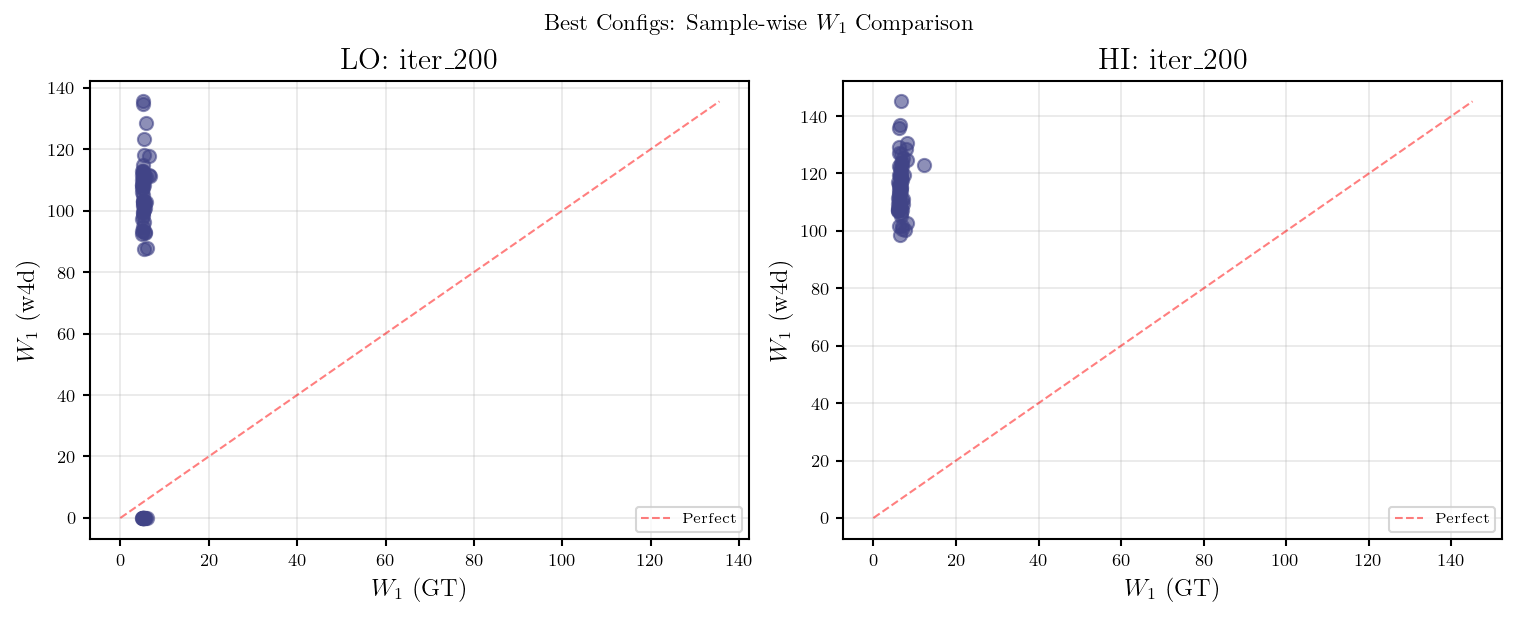

In [22]:
# Scatter: w4d vs GT W1 for best config
best_lo = comparison_df[comparison_df["freq"] == "lo"].nsmallest(1, "w1_median").iloc[0]
best_hi = comparison_df[comparison_df["freq"] == "hi"].nsmallest(1, "w1_median").iloc[0]

fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, best in zip(axs, [best_lo, best_hi]):
    cfg = best["config"]
    freq = best["freq"]
    df = configs[cfg]["data"]
    
    gt = df[(df["freq"] == freq) & (df["method"] == "ground-truth")][["i", "w1"]]
    w4d = df[(df["freq"] == freq) & (df["method"] == "weak-4dvar")][["i", "w1"]]
    merged = gt.merge(w4d, on="i", suffixes=("_gt", "_w4d"))
    
    ax.scatter(merged["w1_gt"], merged["w1_w4d"], alpha=0.6, s=40)
    lim = max(merged[["w1_gt", "w1_w4d"]].max())
    ax.plot([0, lim], [0, lim], "r--", alpha=0.5, label="Perfect")
    ax.set_xlabel(r"$W_1$ (GT)"), ax.set_ylabel(r"$W_1$ (w4d)"), ax.legend()
    ax.set_title(f"{freq.upper()}: {cfg.replace('results_seed_42_', '')}")
    ax.grid(alpha=0.3)

plt.suptitle(r"Best Configs: Sample-wise $W_1$ Comparison", fontsize=11)
plt.show()

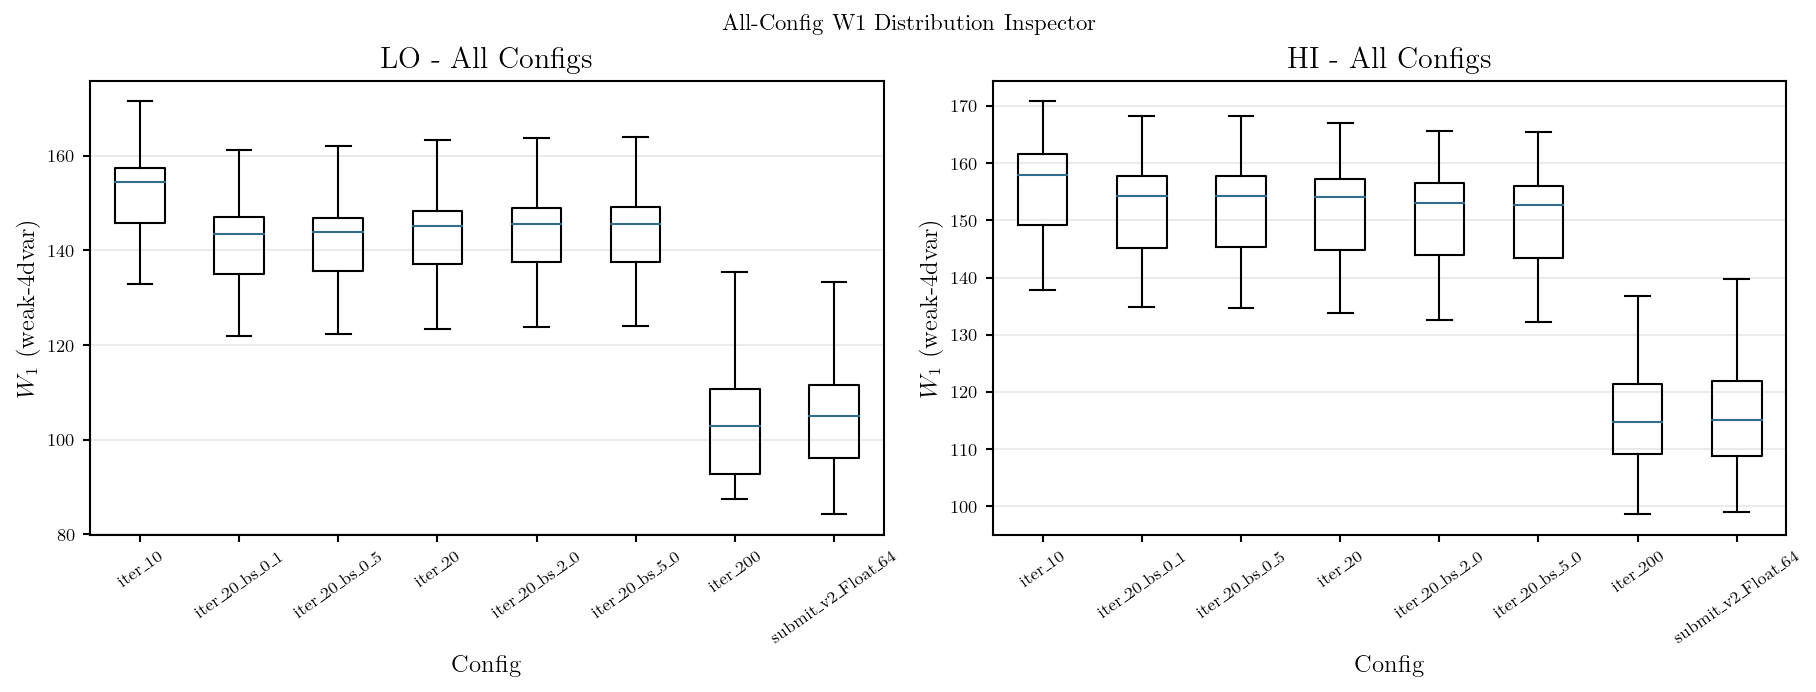

In [23]:
# All-config inspector: W1 distribution summary across all configs
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

config_names = list(configs.keys())
pretty_names = [c.replace("results_seed_42_", "").replace("results8_", "") for c in config_names]

for idx, freq in enumerate(["lo", "hi"]):
    data_for_box = []
    for cfg in config_names:
        df = configs[cfg]["data"]
        w4d_w1 = df[(df["freq"] == freq) & (df["method"] == "weak-4dvar")]["w1"]
        data_for_box.append(w4d_w1.values)

    axs[idx].boxplot(data_for_box, labels=pretty_names, showfliers=False)
    axs[idx].tick_params(axis="x", rotation=35, labelsize=8)
    axs[idx].set_xlabel("Config")
    axs[idx].set_ylabel(r"$W_1$ (weak-4dvar)")
    axs[idx].set_title(f"{freq.upper()} - All Configs")
    axs[idx].grid(alpha=0.3, axis="y")

plt.suptitle("All-Config W1 Distribution Inspector", fontsize=11)
plt.show()

## 7. Detailed Inspection

- iter: 10, 20, 200
- bs: 0.1, 1.0, 2.0  
- Metric: W₁ ratio (w4d / GT)

## Configuration Comparison

### Detailed Inspection